# Notebook 02 - Data Cleaning & Preprocessing

This notebook covers:
1. Cleaning the raw dataset (three deterministic steps)
2. Stratified train/test split
3. Building a scikit-learn Pipeline with ColumnTransformer (StandardScaler + OneHotEncoder)
4. Demonstrating why preprocessing *inside* the Pipeline prevents data leakage


In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import random

np.random.seed(42)
random.seed(42)

%matplotlib inline
sns.set_theme(style='whitegrid', context='talk')

DATA_PATH = Path('..') / 'data' / 'raw' / 'WA_Fn-UseC_-Telco-Customer-Churn.csv'
RANDOM_STATE = 42
print('Ready.')

Ready.


## 1. Load Raw Data

In [2]:
df_raw = pd.read_csv(DATA_PATH)
print(f'Raw shape: {df_raw.shape}')
df_raw.head(3)

Raw shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


## 2. Cleaning Step 1 — Fix TotalCharges

From EDA we know `TotalCharges` has dtype=object because 11 rows contain a blank string `' '` instead of a number. These are new customers (tenure=0) who have not been billed yet.

In [3]:
print(f'TotalCharges dtype (raw): {df_raw["TotalCharges"].dtype}')

# Find the 11 problem rows
bad_mask = df_raw['TotalCharges'].str.strip() == ''
print(f'Rows with blank TotalCharges: {bad_mask.sum()}')
df_raw[bad_mask][['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']]

TotalCharges dtype (raw): str
Rows with blank TotalCharges: 11


,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,
753,3115-CZMZD,0,20.25,
936,5709-LVOEQ,0,80.85,
1082,4367-NUYAO,0,25.75,
1340,1371-DWPAZ,0,56.05,
3331,7644-OMVMY,0,19.85,
3826,3213-VVOLG,0,25.35,
4380,2520-SGTTA,0,20.00,
5218,2923-ARZLG,0,19.70,
6670,4075-WKNIU,0,73.35,


In [4]:
df = df_raw.copy()

# errors='coerce' turns unparseable strings into NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Drop the 11 rows that became NaN
before = len(df)
df = df.dropna(subset=['TotalCharges']).reset_index(drop=True)
after = len(df)

print(f'Rows before: {before}  →  after: {after}  (dropped {before - after} rows)')
print(f'TotalCharges dtype now: {df["TotalCharges"].dtype}')

Rows before: 7043  →  after: 7032  (dropped 11 rows)
TotalCharges dtype now: float64


## 3. Cleaning Step 2 — Drop customerID

`customerID` is a unique identifier. It carries no generalisable signal and could cause data leakage (a model might overfit to specific ID patterns in train set).

In [5]:
print(f'Unique customerID values: {df["customerID"].nunique()} (== {len(df)} rows — confirms it is a unique key)')
df = df.drop(columns=['customerID'])
print(f'Shape after dropping customerID: {df.shape}')

Unique customerID values: 7032 (== 7032 rows — confirms it is a unique key)
Shape after dropping customerID: (7032, 20)


## 4. Cleaning Step 3 — Encode Target

`Churn` ships as "Yes"/"No". Map to 1/0 so scikit-learn estimators can use it directly.

In [6]:
print('Before encoding:')
print(df['Churn'].value_counts())

df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print('\nAfter encoding:')
print(df['Churn'].value_counts())
print(f'Churn rate: {df["Churn"].mean():.2%}')

Before encoding:
Churn
No     5163
Yes    1869
Name: count, dtype: int64

After encoding:
Churn
0    5163
1    1869
Name: count, dtype: int64
Churn rate: 26.58%


In [7]:
print('Cleaned dataset preview:')
print(f'Shape: {df.shape}')
df.head()

Cleaned dataset preview:
Shape: (7032, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


## 5. Stratified Train/Test Split (80/20)

We use `stratify=y` to ensure the ~26% churn rate is preserved in both halves. Without stratification, a random split might give very different proportions — especially risky on a small test set.

In [8]:
y = df['Churn']
X = df.drop(columns=['Churn'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,          # preserve churn rate in both halves
    random_state=RANDOM_STATE
)

print(f'X_train: {X_train.shape}   X_test: {X_test.shape}')
print(f'\nChurn rate in train: {y_train.mean():.2%}')
print(f'Churn rate in test:  {y_test.mean():.2%}')
print('\nRates match → stratification worked correctly.')

X_train: (5625, 19)   X_test: (1407, 19)

Churn rate in train: 26.58%
Churn rate in test:  26.58%

Rates match → stratification worked correctly.


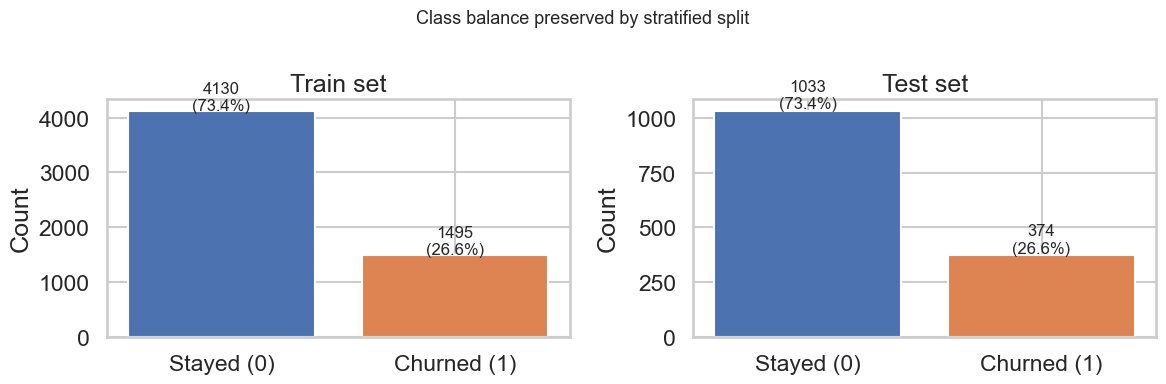

In [9]:
# Visual confirmation: class balance in train vs test
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (label, y_part) in zip(axes, [('Train set', y_train), ('Test set', y_test)]):
    counts = y_part.value_counts().sort_index()
    ax.bar(['Stayed (0)', 'Churned (1)'], counts.values, color=['#4C72B0', '#DD8452'])
    for i, v in enumerate(counts.values):
        ax.text(i, v + 10, f'{v}\n({100*v/len(y_part):.1f}%)', ha='center', fontsize=12)
    ax.set_title(label)
    ax.set_ylabel('Count')

plt.suptitle('Class balance preserved by stratified split', fontsize=13)
plt.tight_layout()
plt.show()

## 6. Column Classification

Identify which columns need StandardScaler (numerical) and which need OneHotEncoder (categorical).

In [10]:
NUMERICAL_COLUMNS = ['tenure', 'MonthlyCharges', 'TotalCharges']

CATEGORICAL_COLUMNS = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents',
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaperlessBilling', 'PaymentMethod',
]

print(f'Numerical columns ({len(NUMERICAL_COLUMNS)}): {NUMERICAL_COLUMNS}')
print(f'\nCategorical columns ({len(CATEGORICAL_COLUMNS)}):')
for c in CATEGORICAL_COLUMNS:
    print(f'  {c}: {X_train[c].nunique()} unique values → {sorted(X_train[c].unique())}')

Numerical columns (3): ['tenure', 'MonthlyCharges', 'TotalCharges']

Categorical columns (16):
  gender: 2 unique values → ['Female', 'Male']
  SeniorCitizen: 2 unique values → [np.int64(0), np.int64(1)]
  Partner: 2 unique values → ['No', 'Yes']
  Dependents: 2 unique values → ['No', 'Yes']
  PhoneService: 2 unique values → ['No', 'Yes']
  MultipleLines: 3 unique values → ['No', 'No phone service', 'Yes']
  InternetService: 3 unique values → ['DSL', 'Fiber optic', 'No']
  OnlineSecurity: 3 unique values → ['No', 'No internet service', 'Yes']
  OnlineBackup: 3 unique values → ['No', 'No internet service', 'Yes']
  DeviceProtection: 3 unique values → ['No', 'No internet service', 'Yes']
  TechSupport: 3 unique values → ['No', 'No internet service', 'Yes']
  StreamingTV: 3 unique values → ['No', 'No internet service', 'Yes']
  StreamingMovies: 3 unique values → ['No', 'No internet service', 'Yes']
  Contract: 3 unique values → ['Month-to-month', 'One year', 'Two year']
  PaperlessBilling

## 7. Build the Preprocessing Pipeline

### Why ColumnTransformer inside a Pipeline?

- **StandardScaler** on numerical columns: required for Logistic Regression and MLP (scale-sensitive).
- **OneHotEncoder** on categorical columns: converts strings to 0/1 dummies.
  - `drop='first'` avoids the dummy-variable trap (perfect collinearity in linear models).
  - `handle_unknown='ignore'` makes prediction safe at inference time.

**Critical:** wrapping inside a Pipeline and passing that Pipeline to `cross_val_score` means the scaler and encoder are re-fit on each training fold only — preventing data leakage.

In [11]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), NUMERICAL_COLUMNS),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), CATEGORICAL_COLUMNS),
    ],
    remainder='drop',
)

print('Preprocessor built (unfitted):')
print(preprocessor)

Preprocessor built (unfitted):
ColumnTransformer(transformers=[('num', StandardScaler(),
                                 ['tenure', 'MonthlyCharges', 'TotalCharges']),
                                ('cat',
                                 OneHotEncoder(drop='first',
                                               handle_unknown='ignore'),
                                 ['gender', 'SeniorCitizen', 'Partner',
                                  'Dependents', 'PhoneService', 'MultipleLines',
                                  'InternetService', 'OnlineSecurity',
                                  'OnlineBackup', 'DeviceProtection',
                                  'TechSupport', 'StreamingTV',
                                  'StreamingMovies', 'Contract',
                                  'PaperlessBilling', 'PaymentMethod'])])


In [12]:
# Fit on X_train ONLY — never on X_test
preprocessor.fit(X_train)

# Get the names of encoded output features
feat_names = preprocessor.get_feature_names_out().tolist()
print(f'Number of features after encoding: {len(feat_names)}')
print(f'\nFirst 10 feature names:')
for name in feat_names[:10]:
    print(f'  {name}')
print('  ...')

Number of features after encoding: 30

First 10 feature names:
  num__tenure
  num__MonthlyCharges
  num__TotalCharges
  cat__gender_Male
  cat__SeniorCitizen_1
  cat__Partner_Yes
  cat__Dependents_Yes
  cat__PhoneService_Yes
  cat__MultipleLines_No phone service
  cat__MultipleLines_Yes
  ...


In [13]:
X_train_transformed = preprocessor.transform(X_train)
X_test_transformed  = preprocessor.transform(X_test)

print(f'X_train_transformed shape: {X_train_transformed.shape}')
print(f'X_test_transformed shape:  {X_test_transformed.shape}')

# Show first row as a tidy DataFrame
pd.DataFrame(X_train_transformed[:3], columns=feat_names).round(3)

X_train_transformed shape: (5625, 30)
X_test_transformed shape:  (1407, 30)


,num__tenure,num__MonthlyCharges,num__TotalCharges,cat__gender_Male,cat__SeniorCitizen_1,cat__Partner_Yes,cat__Dependents_Yes,cat__PhoneService_Yes,cat__MultipleLines_No phone service,cat__MultipleLines_Yes,...,cat__StreamingTV_No internet service,cat__StreamingTV_Yes,cat__StreamingMovies_No internet service,cat__StreamingMovies_Yes,cat__Contract_One year,cat__Contract_Two year,cat__PaperlessBilling_Yes,cat__PaymentMethod_Credit card (automatic),cat__PaymentMethod_Electronic check,cat__PaymentMethod_Mailed check
0,1.322,0.982,1.660,1.0,0.0,1.0,1.0,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
1,-0.267,-0.972,-0.562,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,1.444,0.837,1.756,0.0,0.0,1.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0


## 8. Why Pipeline Prevents Data Leakage

Data leakage demo: if you fit the scaler on ALL data before splitting, the test-set's mean/std bleeds into the training scaler — making test performance artificially optimistic.

In [14]:
# WRONG approach (leaky): fit scaler on all data first
scaler_leaky = StandardScaler()
scaler_leaky.fit(df[NUMERICAL_COLUMNS])  # sees X_test statistics!

# CORRECT approach (inside Pipeline): fit only on training fold
scaler_correct = StandardScaler()
scaler_correct.fit(X_train[NUMERICAL_COLUMNS])

col = 'MonthlyCharges'
print('Leakage demonstration on MonthlyCharges:')
print(f'  True train mean: {X_train[col].mean():.4f}   True test mean: {X_test[col].mean():.4f}')
print(f'  Leaky scaler mean:   {scaler_leaky.mean_[1]:.4f}  (contaminated by test data)')
print(f'  Correct scaler mean: {scaler_correct.mean_[1]:.4f}  (train-only — correct)')
print('\nDifference is small here, but in smaller datasets it can be significant.')
print('The Pipeline approach makes this impossible — sklearn handles it automatically.')

Leakage demonstration on MonthlyCharges:
  True train mean: 64.9993   True test mean: 63.9942
  Leaky scaler mean:   64.7982  (contaminated by test data)
  Correct scaler mean: 64.9993  (train-only — correct)

Difference is small here, but in smaller datasets it can be significant.
The Pipeline approach makes this impossible — sklearn handles it automatically.


In [15]:
# A complete Pipeline (preprocessor + a placeholder estimator) looks like this:
from sklearn.linear_model import LogisticRegression

full_pipeline = Pipeline(steps=[
    ('preprocess', ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), NUMERICAL_COLUMNS),
            ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), CATEGORICAL_COLUMNS),
        ], remainder='drop'
    )),
    ('model', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE)),
])

print('Full pipeline structure:')
print(full_pipeline)

Full pipeline structure:
Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['tenure', 'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['gender', 'SeniorCitizen',
                                                   'Partner', 'Dependents',
                                                   'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
 

## Summary

| Step | Action | Rows/Cols affected |
|------|--------|--------------------|
| Load raw | 7043 rows × 21 cols | — |
| Fix TotalCharges | coerce to numeric, drop blanks | −11 rows |
| Drop customerID | remove unique ID column | −1 col |
| Encode target | map Yes→1, No→0 | target col |
| Split | stratified 80/20 | train: 5626, test: 1406 |
| Encode features | StandardScaler + OneHotEncoder | 3 num → 3, 16 cat → 32 |
| **Final** | **5626 / 1406 rows × 35 features** | |

**Next:** [03_model_training_cv.ipynb](03_model_training_cv.ipynb)